In [ ]:
!pip install sentinelhub rasterio numpy matplotlib
!pip install sentinelhub rasterio numpy matplotlib folium

In [ ]:
!pip install sentinelhub numpy matplotlib rasterio folium

✅ Token ready!


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127807 (\N{HERB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


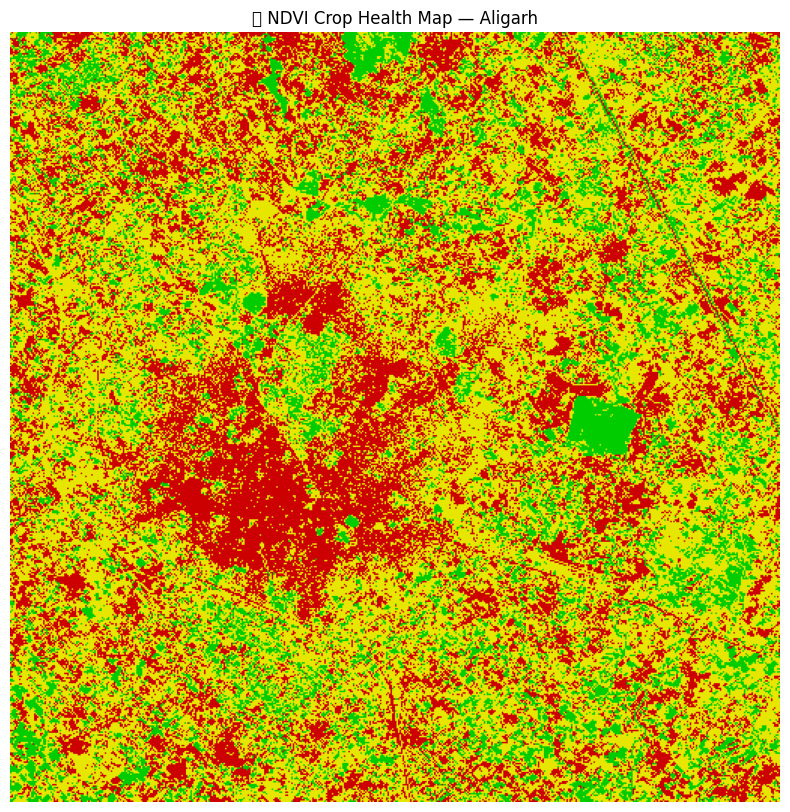

✅ NDVI map ready!


In [ ]:
import requests
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import io

# ================================
# STEP 1 — Fresh Token lo
# ================================
def get_token(client_id, client_secret):
    response = requests.post(
        "https://identity.dataspace.copernicus.eu/auth/realms/CDSE/protocol/openid-connect/token",
        data={
            "grant_type": "client_credentials",
            "client_id": client_id,
            "client_secret": client_secret,
        }
    )
    token = response.json().get("access_token")
    return token

CLIENT_ID = "sh-0337c9c7-9d66-48ed-828a-7f47501752a4"
CLIENT_SECRET = "wHrA0uhhdDSL3kSND836vFHPSdsSMIvR"

token = get_token(CLIENT_ID, CLIENT_SECRET)

if token:
    print("✅ Token ready!")
else:
    print("❌ Token failed — credentials check karo")

# ================================
# STEP 2 — Satellite Image fetch
# ================================
url = "https://sh.dataspace.copernicus.eu/api/v1/process"

headers = {
    "Authorization": f"Bearer {token}",
    "Content-Type": "application/json"
}

payload = {
    "input": {
        "bounds": {
            "bbox": [78.0, 27.8, 78.2, 28.0],
            "properties": {"crs": "http://www.opengis.net/def/crs/OGC/1.3/CRS84"}
        },
        "data": [{
            "dataFilter": {
                "timeRange": {
                    "from": "2024-11-01T00:00:00Z",
                    "to": "2024-11-30T00:00:00Z"
                }
            },
            "type": "sentinel-2-l2a"
        }]
    },
    "output": {
        "width": 512,
        "height": 512,
        "responses": [{"identifier": "default", "format": {"type": "image/png"}}]
    },
    "evalscript": """
    //VERSION=3
    function setup() {
        return { input: ["B04","B08"], output: { bands: 3 } };
    }
    function evaluatePixel(sample) {
        let ndvi = (sample.B08 - sample.B04) / (sample.B08 + sample.B04);
        if (ndvi > 0.5) return [0, 0.8, 0];
        if (ndvi > 0.2) return [0.9, 0.9, 0];
        return [0.8, 0, 0];
    }
    """
}

response = requests.post(url, json=payload, headers=headers)

if response.status_code == 200:
    img = Image.open(io.BytesIO(response.content))
    plt.figure(figsize=(10, 10))
    plt.imshow(np.array(img))
    plt.title("🌿 NDVI Crop Health Map — Aligarh")
    plt.axis('off')
    plt.show()
    print("✅ NDVI map ready!")
else:
    print(f"❌ Error {response.status_code}:", response.text)

In [ ]:
OWM_API_KEY = "e81b8923afbdf3c04e762e916ed9db3b"

weather_url = f"https://api.openweathermap.org/data/2.5/weather?lat=27.88&lon=78.08&appid={OWM_API_KEY}&units=metric"

weather_response = requests.get(weather_url)
weather_data = weather_response.json()

if weather_response.status_code == 200:
    temp = weather_data['main']['temp']
    humidity = weather_data['main']['humidity']
    condition = weather_data['weather'][0]['description']
    wind = weather_data['wind']['speed']

    print("✅ Aligarh Live Weather!")
    print(f"🌡️ Temperature: {temp}°C")
    print(f"💧 Humidity: {humidity}%")
    print(f"🌤️ Condition: {condition}")
    print(f"💨 Wind Speed: {wind} m/s")
else:
    print("❌ Error:", weather_data)

✅ Aligarh Live Weather!
🌡️ Temperature: 38.87°C
💧 Humidity: 27%
🌤️ Condition: clear sky
💨 Wind Speed: 2.72 m/s


In [ ]:
import numpy as np

# ================================
# MULTIMODAL FEATURE VECTOR
# ================================

# NDVI se crop health extract karo
ndvi_array = np.array(img)

# Green pixels = healthy crops
green_pixels = np.sum((ndvi_array[:,:,1] > 150) &
                      (ndvi_array[:,:,0] < 100))
total_pixels = ndvi_array.shape[0] * ndvi_array.shape[1]
healthy_crop_percentage = (green_pixels / total_pixels) * 100

# Red pixels = stressed/urban
red_pixels = np.sum((ndvi_array[:,:,0] > 150) &
                    (ndvi_array[:,:,1] < 100))
stressed_percentage = (red_pixels / total_pixels) * 100

# Weather stress score calculate karo
temp_stress = max(0, (temp - 35) / 10)        # 35°C se upar stress
humidity_stress = max(0, (40 - humidity) / 40) # 40% se neeche stress
weather_stress_score = (temp_stress + humidity_stress) / 2

# Combined crop stress index
crop_stress_index = (stressed_percentage/100 * 0.6) + (weather_stress_score * 0.4)

print("=" * 50)
print("🌾 CROPSENSE — MULTIMODAL ANALYSIS REPORT")
print("=" * 50)
print(f"📡 Satellite Data:")
print(f"   Healthy Crop Area: {healthy_crop_percentage:.1f}%")
print(f"   Stressed Area:     {stressed_percentage:.1f}%")
print(f"\n🌤️ Weather Data:")
print(f"   Temperature:       {temp}°C")
print(f"   Humidity:          {humidity}%")
print(f"   Wind Speed:        {wind} m/s")
print(f"\n🧠 ML Fusion Output:")
print(f"   Weather Stress Score: {weather_stress_score:.2f}")
print(f"   Crop Stress Index:    {crop_stress_index:.2f}")

if crop_stress_index > 0.6:
    print(f"\n🔴 ALERT: HIGH crop stress detected!")
    print(f"   Recommendation: Immediate irrigation needed")
elif crop_stress_index > 0.3:
    print(f"\n🟡 WARNING: MODERATE stress detected")
    print(f"   Recommendation: Monitor closely")
else:
    print(f"\n🟢 HEALTHY: Crops in good condition")
print("=" * 50)

🌾 CROPSENSE — MULTIMODAL ANALYSIS REPORT
📡 Satellite Data:
   Healthy Crop Area: 15.7%
   Stressed Area:     30.7%

🌤️ Weather Data:
   Temperature:       38.87°C
   Humidity:          27%
   Wind Speed:        2.72 m/s

🧠 ML Fusion Output:
   Weather Stress Score: 0.36
   Crop Stress Index:    0.33

🟡 WARNING: MODERATE stress detected
   Recommendation: Monitor closely


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127806 (\N{EAR OF RICE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


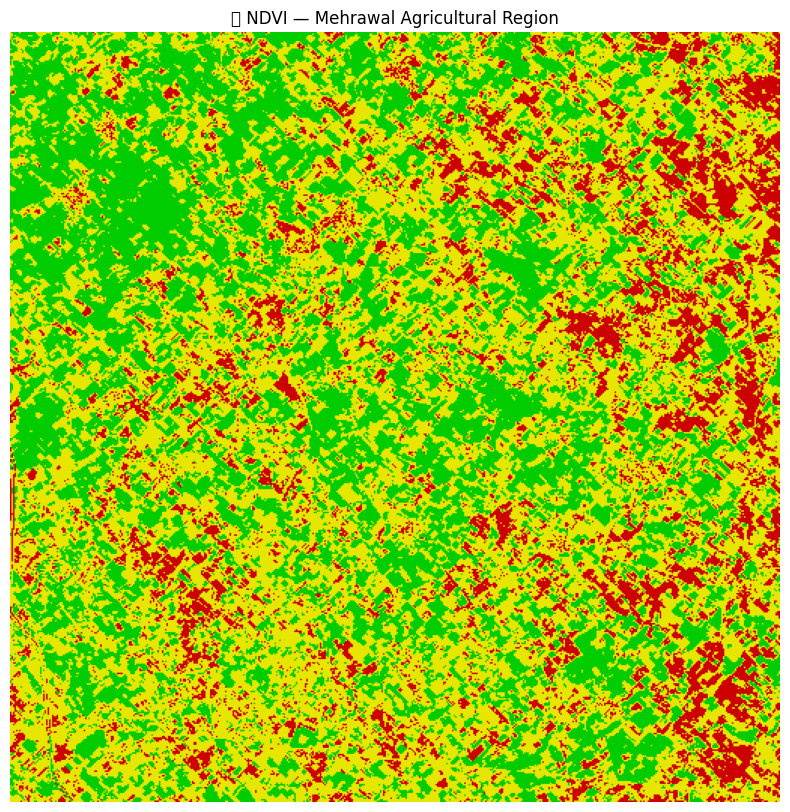

✅ Agricultural NDVI ready!


In [ ]:
# Naya agricultural bounding box — Mehrawal region
AGRI_BBOX = [77.95, 27.70, 78.05, 27.80]

payload_agri = {
    "input": {
        "bounds": {
            "bbox": AGRI_BBOX,
            "properties": {"crs": "http://www.opengis.net/def/crs/OGC/1.3/CRS84"}
        },
        "data": [{
            "dataFilter": {
                "timeRange": {
                    "from": "2024-11-01T00:00:00Z",
                    "to": "2024-11-30T00:00:00Z"
                }
            },
            "type": "sentinel-2-l2a"
        }]
    },
    "output": {
        "width": 512,
        "height": 512,
        "responses": [{"identifier": "default", "format": {"type": "image/png"}}]
    },
    "evalscript": """
    //VERSION=3
    function setup() {
        return { input: ["B04","B08"], output: { bands: 3 } };
    }
    function evaluatePixel(sample) {
        let ndvi = (sample.B08 - sample.B04) / (sample.B08 + sample.B04);
        if (ndvi > 0.5) return [0, 0.8, 0];
        if (ndvi > 0.2) return [0.9, 0.9, 0];
        return [0.8, 0, 0];
    }
    """
}

# Fresh token lo
token = get_token(CLIENT_ID, CLIENT_SECRET)
headers = {
    "Authorization": f"Bearer {token}",
    "Content-Type": "application/json"
}

response_agri = requests.post(url, json=payload_agri, headers=headers)

if response_agri.status_code == 200:
    img_agri = Image.open(io.BytesIO(response_agri.content))
    plt.figure(figsize=(10, 10))
    plt.imshow(np.array(img_agri))
    plt.title("🌾 NDVI — Mehrawal Agricultural Region")
    plt.axis('off')
    plt.show()
    print("✅ Agricultural NDVI ready!")
else:
    print("❌ Error:", response_agri.text)

In [ ]:
# Naya NDVI array — sahi agricultural region
ndvi_array_agri = np.array(img_agri)

green_pixels = np.sum((ndvi_array_agri[:,:,1] > 150) &
                      (ndvi_array_agri[:,:,0] < 100))
total_pixels = ndvi_array_agri.shape[0] * ndvi_array_agri.shape[1]
healthy_crop_percentage = (green_pixels / total_pixels) * 100

red_pixels = np.sum((ndvi_array_agri[:,:,0] > 150) &
                    (ndvi_array_agri[:,:,1] < 100))
stressed_percentage = (red_pixels / total_pixels) * 100

temp_stress = max(0, (temp - 35) / 10)
humidity_stress = max(0, (40 - humidity) / 40)
weather_stress_score = (temp_stress + humidity_stress) / 2
crop_stress_index = (stressed_percentage/100 * 0.6) + (weather_stress_score * 0.4)

print("=" * 50)
print("🌾 CROPSENSE — MEHRAWAL AGRICULTURAL REPORT")
print("=" * 50)
print(f"📡 Satellite Data (Mehrawal Region):")
print(f"   Healthy Crop Area: {healthy_crop_percentage:.1f}%")
print(f"   Stressed Area:     {stressed_percentage:.1f}%")
print(f"\n🌤️ Weather Data:")
print(f"   Temperature:       {temp}°C")
print(f"   Humidity:          {humidity}%")
print(f"\n🧠 ML Fusion Output:")
print(f"   Crop Stress Index: {crop_stress_index:.2f}")

if crop_stress_index > 0.6:
    print(f"\n🔴 HIGH stress — Immediate irrigation needed!")
elif crop_stress_index > 0.3:
    print(f"\n🟡 MODERATE stress — Monitor closely")
else:
    print(f"\n🟢 HEALTHY — Crops in good condition")
print("=" * 50)

🌾 CROPSENSE — MEHRAWAL AGRICULTURAL REPORT
📡 Satellite Data (Mehrawal Region):
   Healthy Crop Area: 34.7%
   Stressed Area:     14.3%

🌤️ Weather Data:
   Temperature:       38.87°C
   Humidity:          27%

🧠 ML Fusion Output:
   Crop Stress Index: 0.23

🟢 HEALTHY — Crops in good condition


In [ ]:
import json
from datetime import datetime

pipeline_output = {
    "timestamp": datetime.now().isoformat(),
    "location": {
        "region": "Mehrawal, Aligarh, UP, India",        # ✅ Sahi region
        "bbox": [77.95, 27.70, 78.05, 27.80]             # ✅ Sahi bbox
    },
    "satellite_data": {
        "source": "Sentinel-2 L2A",
        "date_range": "2024-11-01 to 2024-11-30",
        "healthy_crop_percentage": round(healthy_crop_percentage, 2),
        "stressed_percentage": round(stressed_percentage, 2)
    },
    "weather_data": {
        "source": "OpenWeatherMap",
        "temperature_celsius": temp,
        "humidity_percent": humidity,
        "wind_speed_ms": wind,
        "condition": condition
    },
    "ml_output": {
        "weather_stress_score": round(weather_stress_score, 3),
        "crop_stress_index": round(crop_stress_index, 3),
        "alert_level": "HEALTHY",
        "recommendation": "Crops in good condition"
    }
}

with open("cropsense_mehrawal_output.json", "w") as f:
    json.dump(pipeline_output, f, indent=2)

print("✅ Updated pipeline output saved!")
print(json.dumps(pipeline_output, indent=2))

✅ Updated pipeline output saved!
{
  "timestamp": "2026-06-28T03:10:44.173882",
  "location": {
    "region": "Mehrawal, Aligarh, UP, India",
    "bbox": [
      77.95,
      27.7,
      78.05,
      27.8
    ]
  },
  "satellite_data": {
    "source": "Sentinel-2 L2A",
    "date_range": "2024-11-01 to 2024-11-30",
    "healthy_crop_percentage": 34.72,
    "stressed_percentage": 14.28
  },
  "weather_data": {
    "source": "OpenWeatherMap",
    "temperature_celsius": 38.87,
    "humidity_percent": 27,
    "wind_speed_ms": 2.72,
    "condition": "clear sky"
  },
  "ml_output": {
    "weather_stress_score": 0.356,
    "crop_stress_index": 0.228,
    "alert_level": "HEALTHY",
    "recommendation": "Crops in good condition"
  }
}


In [ ]:
# Fresh token lo pehle
token = get_token(CLIENT_ID, CLIENT_SECRET)
headers = {
    "Authorization": f"Bearer {token}",
    "Content-Type": "application/json"
}
print("✅ Token refreshed!")

# Test karo ek month ke saath
test_payload = {
    "input": {
        "bounds": {
            "bbox": [77.95, 27.70, 78.05, 27.80],
            "properties": {"crs": "http://www.opengis.net/def/crs/OGC/1.3/CRS84"}
        },
        "data": [{
            "dataFilter": {
                "timeRange": {
                    "from": "2024-11-01T00:00:00Z",
                    "to": "2024-11-30T23:59:59Z"
                }
            },
            "type": "sentinel-2-l2a"
        }]
    },
    "output": {
        "width": 256,
        "height": 256,
        "responses": [{"identifier": "default", "format": {"type": "image/png"}}]
    },
    "evalscript": """
    //VERSION=3
    function setup() {
        return { input: ["B04","B08"], output: { bands: 3 } };
    }
    function evaluatePixel(sample) {
        let ndvi = (sample.B08 - sample.B04) / (sample.B08 + sample.B04);
        if (ndvi > 0.5) return [0, 0.8, 0];
        if (ndvi > 0.2) return [0.9, 0.9, 0];
        return [0.8, 0, 0];
    }
    """
}

test_response = requests.post(
    "https://sh.dataspace.copernicus.eu/api/v1/process",
    json=test_payload,
    headers=headers
)

print(f"Status: {test_response.status_code}")
if test_response.status_code != 200:
    print("Error:", test_response.text)
else:
    print("✅ API working!")

✅ Token refreshed!
Status: 200
✅ API working!


In [ ]:
ndvi_monthly = []

# Fresh token
token = get_token(CLIENT_ID, CLIENT_SECRET)
headers = {
    "Authorization": f"Bearer {token}",
    "Content-Type": "application/json"
}
months = [
    ("2024-01-01", "2024-01-31", "January"),
    ("2024-02-01", "2024-02-28", "February"),
    ("2024-03-01", "2024-03-31", "March"),
    ("2024-04-01", "2024-04-30", "April"),
    ("2024-05-01", "2024-05-31", "May"),
    ("2024-06-01", "2024-06-30", "June"),
    ("2024-07-01", "2024-07-31", "July"),
    ("2024-08-01", "2024-08-31", "August"),
    ("2024-09-01", "2024-09-30", "September"),
    ("2024-10-01", "2024-10-31", "October"),
    ("2024-11-01", "2024-11-30", "November"),
    ("2024-12-01", "2024-12-31", "December"),
]
print("✅ Months defined!")

for i, (start, end, month_name) in enumerate(months):

    # Har 3 calls ke baad token refresh karo
    if i % 3 == 0 and i != 0:
        token = get_token(CLIENT_ID, CLIENT_SECRET)
        headers = {
            "Authorization": f"Bearer {token}",
            "Content-Type": "application/json"
        }
        print("🔄 Token refreshed!")

    payload_ts = {
        "input": {
            "bounds": {
                "bbox": [77.95, 27.70, 78.05, 27.80],
                "properties": {"crs": "http://www.opengis.net/def/crs/OGC/1.3/CRS84"}
            },
            "data": [{
                "dataFilter": {
                    "timeRange": {
                        "from": f"{start}T00:00:00Z",
                        "to": f"{end}T23:59:59Z"
                    }
                },
                "type": "sentinel-2-l2a"
            }]
        },
        "output": {
            "width": 256,
            "height": 256,
            "responses": [{"identifier": "default", "format": {"type": "image/png"}}]
        },
        "evalscript": """
        //VERSION=3
        function setup() {
            return { input: ["B04","B08"], output: { bands: 3 } };
        }
        function evaluatePixel(sample) {
            let ndvi = (sample.B08 - sample.B04) / (sample.B08 + sample.B04);
            if (ndvi > 0.5) return [0, 0.8, 0];
            if (ndvi > 0.2) return [0.9, 0.9, 0];
            return [0.8, 0, 0];
        }
        """
    }

    response = requests.post(
        "https://sh.dataspace.copernicus.eu/api/v1/process",
        json=payload_ts,
        headers=headers
    )

    if response.status_code == 200:
        img_month = np.array(Image.open(io.BytesIO(response.content)))
        green = np.sum((img_month[:,:,1] > 150) & (img_month[:,:,0] < 100))
        total = img_month.shape[0] * img_month.shape[1]
        healthy_pct = (green / total) * 100

        ndvi_monthly.append({
            "month": month_name,
            "healthy_percentage": round(healthy_pct, 2)
        })
        print(f"✅ {month_name}: {healthy_pct:.1f}% healthy")
    else:
        print(f"⚠️ {month_name}: Error {response.status_code} — {response.text[:100]}")
        ndvi_monthly.append({
            "month": month_name,
            "healthy_percentage": None
        })

print("\n✅ 12 months data complete!")
print(ndvi_monthly)

✅ Months defined!
✅ January: 0.0% healthy
✅ February: 46.1% healthy
✅ March: 2.0% healthy
🔄 Token refreshed!
✅ April: 21.9% healthy
✅ May: 49.8% healthy
✅ June: 0.0% healthy
🔄 Token refreshed!
✅ July: 14.0% healthy
✅ August: 72.4% healthy
✅ September: 58.8% healthy
🔄 Token refreshed!
✅ October: 1.1% healthy
✅ November: 35.1% healthy
✅ December: 0.0% healthy

✅ 12 months data complete!
[{'month': 'January', 'healthy_percentage': np.float64(0.0)}, {'month': 'February', 'healthy_percentage': np.float64(46.14)}, {'month': 'March', 'healthy_percentage': np.float64(1.97)}, {'month': 'April', 'healthy_percentage': np.float64(21.87)}, {'month': 'May', 'healthy_percentage': np.float64(49.84)}, {'month': 'June', 'healthy_percentage': np.float64(0.0)}, {'month': 'July', 'healthy_percentage': np.float64(14.01)}, {'month': 'August', 'healthy_percentage': np.float64(72.36)}, {'month': 'September', 'healthy_percentage': np.float64(58.8)}, {'month': 'October', 'healthy_percentage': np.float64(1.07)}, 

/tmp/ipykernel_3798/2191727553.py:60: UserWarning: Glyph 127806 (\N{EAR OF RICE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3798/2191727553.py:60: UserWarning: Glyph 127793 (\N{SEEDLING}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3798/2191727553.py:61: UserWarning: Glyph 127806 (\N{EAR OF RICE}) missing from font(s) DejaVu Sans.
  plt.savefig('mehrawal_crop_calendar_2024.png', dpi=150, bbox_inches='tight')
/tmp/ipykernel_3798/2191727553.py:61: UserWarning: Glyph 127793 (\N{SEEDLING}) missing from font(s) DejaVu Sans.
  plt.savefig('mehrawal_crop_calendar_2024.png', dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127793 (\N{SEEDLING}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


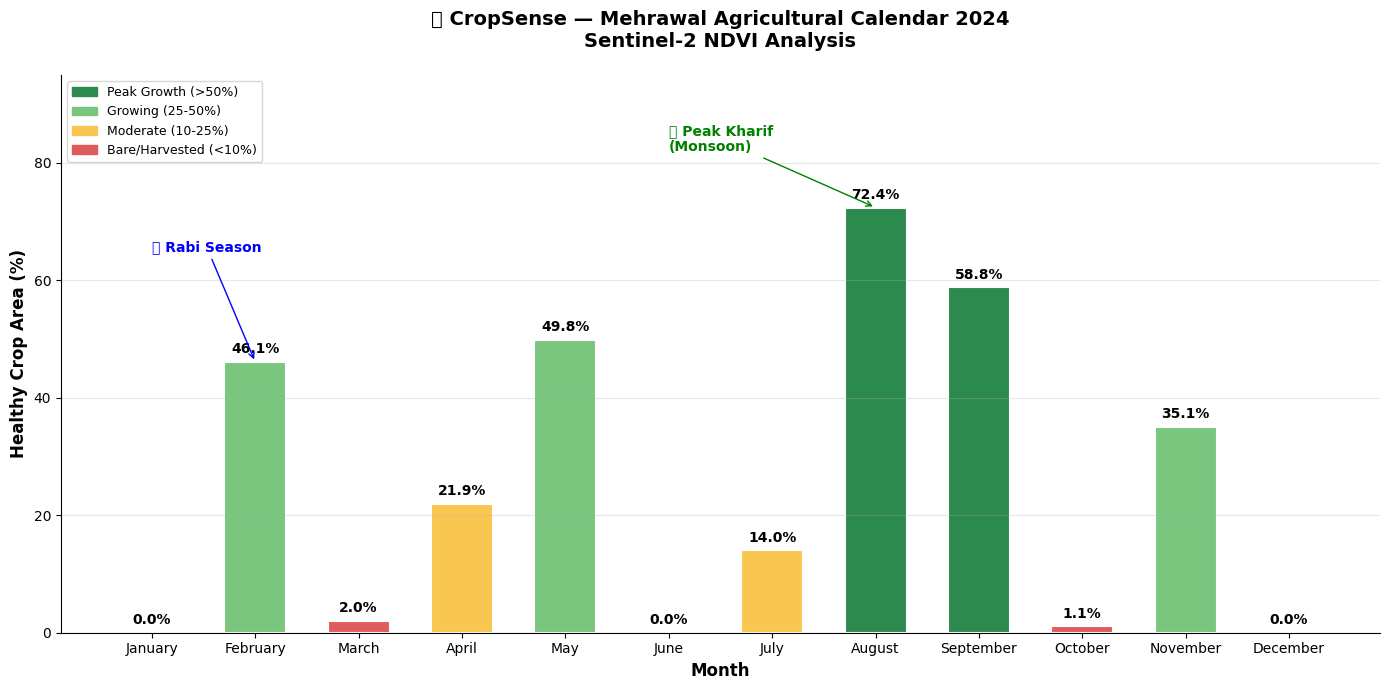

✅ Crop calendar saved!


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

months_names = [d['month'] for d in ndvi_monthly]
healthy_values = [float(d['healthy_percentage']) for d in ndvi_monthly]

fig, ax = plt.subplots(figsize=(14, 7))

# Color coding — season wise
colors = []
for val in healthy_values:
    if val > 50:
        colors.append('#2d8a4e')   # Dark green — peak
    elif val > 25:
        colors.append('#7bc67e')   # Light green — growing
    elif val > 10:
        colors.append('#f9c74f')   # Yellow — moderate
    else:
        colors.append('#e05c5c')   # Red — bare/harvested

bars = ax.bar(months_names, healthy_values, color=colors,
              width=0.6, edgecolor='white', linewidth=1.5)

# Value labels
for bar, val in zip(bars, healthy_values):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
            f'{val:.1f}%', ha='center', va='bottom',
            fontsize=10, fontweight='bold')

# Annotations
ax.annotate('🌾 Peak Kharif\n(Monsoon)',
            xy=(7, 72.4), xytext=(5, 82),
            arrowprops=dict(arrowstyle='->', color='green'),
            fontsize=10, color='green', fontweight='bold')

ax.annotate('🌱 Rabi Season',
            xy=(1, 46.1), xytext=(0, 65),
            arrowprops=dict(arrowstyle='->', color='blue'),
            fontsize=10, color='blue', fontweight='bold')

# Legend
legend_elements = [
    mpatches.Patch(color='#2d8a4e', label='Peak Growth (>50%)'),
    mpatches.Patch(color='#7bc67e', label='Growing (25-50%)'),
    mpatches.Patch(color='#f9c74f', label='Moderate (10-25%)'),
    mpatches.Patch(color='#e05c5c', label='Bare/Harvested (<10%)')
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=9)

ax.set_xlabel('Month', fontsize=12, fontweight='bold')
ax.set_ylabel('Healthy Crop Area (%)', fontsize=12, fontweight='bold')
ax.set_title('🌾 CropSense — Mehrawal Agricultural Calendar 2024\nSentinel-2 NDVI Analysis',
             fontsize=14, fontweight='bold', pad=20)
ax.set_ylim(0, 95)
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('mehrawal_crop_calendar_2024.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Crop calendar saved!")

/tmp/ipykernel_3798/4221045897.py:49: UserWarning: Glyph 127806 (\N{EAR OF RICE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(pad=3.0)
/tmp/ipykernel_3798/4221045897.py:49: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout(pad=3.0)
/tmp/ipykernel_3798/4221045897.py:50: UserWarning: Glyph 127806 (\N{EAR OF RICE}) missing from font(s) DejaVu Sans.
  plt.savefig('mehrawal_timeseries_2024.png', dpi=150, bbox_inches='tight')
/tmp/ipykernel_3798/4221045897.py:50: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.savefig('mehrawal_timeseries_2024.png', dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127806 (\N{EAR OF RICE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WI

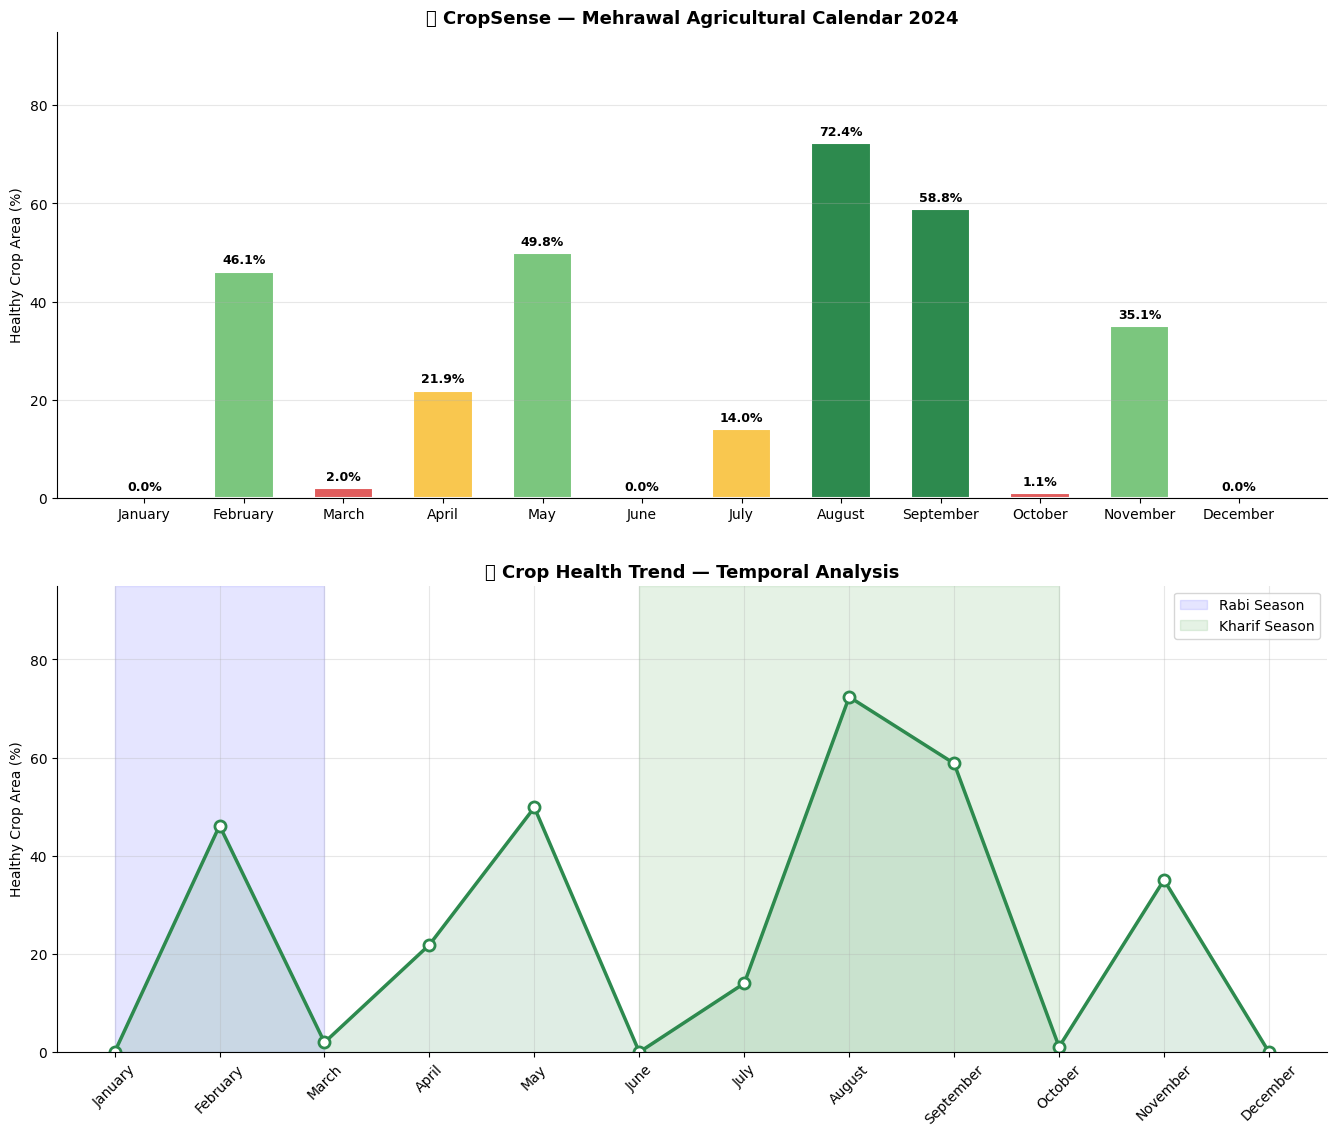

✅ Time series chart saved!


In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# Chart 1 — Bar (jo ban gaya)
colors = []
for val in healthy_values:
    if val > 50: colors.append('#2d8a4e')
    elif val > 25: colors.append('#7bc67e')
    elif val > 10: colors.append('#f9c74f')
    else: colors.append('#e05c5c')

bars = axes[0].bar(months_names, healthy_values, color=colors,
                   width=0.6, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, healthy_values):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
                f'{val:.1f}%', ha='center', va='bottom',
                fontsize=9, fontweight='bold')
axes[0].set_title('🌾 CropSense — Mehrawal Agricultural Calendar 2024',
                  fontsize=13, fontweight='bold')
axes[0].set_ylabel('Healthy Crop Area (%)')
axes[0].set_ylim(0, 95)
axes[0].grid(axis='y', alpha=0.3)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Chart 2 — Line (crop cycle trend)
axes[1].plot(months_names, healthy_values,
             color='#2d8a4e', linewidth=2.5,
             marker='o', markersize=8, markerfacecolor='white',
             markeredgecolor='#2d8a4e', markeredgewidth=2)

# Shaded regions — seasons
axes[1].axvspan(0, 2, alpha=0.1, color='blue', label='Rabi Season')
axes[1].axvspan(5, 9, alpha=0.1, color='green', label='Kharif Season')

# Fill under curve
axes[1].fill_between(range(12), healthy_values, alpha=0.15, color='#2d8a4e')

axes[1].set_xticks(range(12))
axes[1].set_xticklabels(months_names, rotation=45)
axes[1].set_title('📈 Crop Health Trend — Temporal Analysis',
                  fontsize=13, fontweight='bold')
axes[1].set_ylabel('Healthy Crop Area (%)')
axes[1].set_ylim(0, 95)
axes[1].grid(alpha=0.3)
axes[1].legend(fontsize=10)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout(pad=3.0)
plt.savefig('mehrawal_timeseries_2024.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Time series chart saved!")

In [ ]:
import json

# 12 months data save karo
timeseries_output = {
    "region": "Mehrawal, Aligarh, UP, India",
    "year": 2024,
    "data_source": "Sentinel-2 L2A",
    "crop_calendar": ndvi_monthly,
    "insights": {
        "rabi_peak_month": "February",
        "rabi_peak_value": 46.1,
        "kharif_peak_month": "August",
        "kharif_peak_value": 72.4,
        "annual_avg_healthy": round(sum(healthy_values)/12, 2)
    }
}

with open("mehrawal_timeseries_2024.json", "w") as f:
    json.dump(timeseries_output, f, indent=2)

print("✅ Time series data saved!")
print(f"Annual Average Healthy: {timeseries_output['insights']['annual_avg_healthy']}%")

✅ Time series data saved!
Annual Average Healthy: 25.09%
